# 20251211 Analysis (Cytation 3)

In [1]:
!pip install nucleus-cdk==0.5.0rc2 | tail -n2

# Surface a failed install here, rather than as a confusing ModuleNotFoundError
# in the import cell below.
import importlib.metadata as md
assert md.version("nucleus-cdk") == "0.5.0rc2", f"got {md.version('nucleus-cdk')}"

Analyze time-series fluorescence data from PURE (Protein synthesis Using Recombinant Elements) experiments. 

## Setup 

In [2]:
%load_ext autoreload
%autoreload 2
    
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Import the cdk platereader module
from cdk.analysis.cytosol import platereader as pr
import warnings

warnings.filterwarnings('ignore')

# Set up plotting
pr.plot_setup()

## Load Data

In [3]:
# Specify file paths
data_file = "20251211-cytation3-pure-timecourse-gfp-EXPERIMENT-biotek-cdk.txt"
platemap_file = "20251211-ClpXP-Cy3-2.csv"


# Load data
data, platemap = pr.load_platereader_data(
    data_file=data_file,
    platemap_file=platemap_file,
    platereader="biotek-cdk"  # Options: "cytation", "envision", "biotek-cdk"
)

# Checkout first few rows
data.head()

,Time,Well,Data,Row,Column,Read,Clock Time,Experiment,Name,CP
0,0 days 00:00:00,A1,40520,A,1,GFP-F-G35,2025-12-11 15:20:43,ClpXP,ClpX DNA + ClpP DNA + Purified deGFP-ssRA pro...,1
1,0 days 00:05:00,A1,37368,A,1,GFP-F-G35,2025-12-11 15:25:43,ClpXP,ClpX DNA + ClpP DNA + Purified deGFP-ssRA pro...,1
2,0 days 00:10:00,A1,35547,A,1,GFP-F-G35,2025-12-11 15:30:43,ClpXP,ClpX DNA + ClpP DNA + Purified deGFP-ssRA pro...,1
3,0 days 00:15:00,A1,34719,A,1,GFP-F-G35,2025-12-11 15:35:43,ClpXP,ClpX DNA + ClpP DNA + Purified deGFP-ssRA pro...,1
4,0 days 00:20:00,A1,33344,A,1,GFP-F-G35,2025-12-11 15:40:43,ClpXP,ClpX DNA + ClpP DNA + Purified deGFP-ssRA pro...,1


## Plot Raw Curves

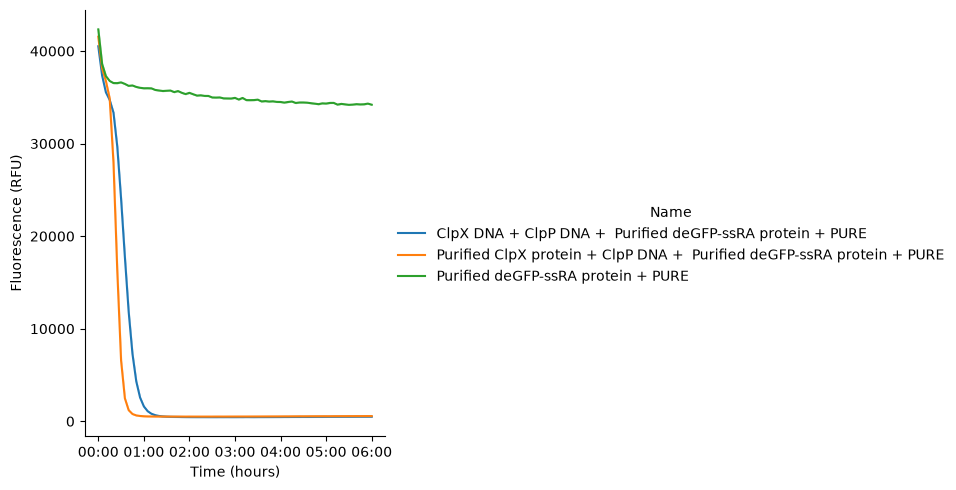

In [4]:
#| label: 20251211-kinetics

g = pr.plot_curves(data=data)